In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("OneDrive/Desktop/python/Telecom_Uptime_Count_Analysis/Monthly GP Uptime.csv", header=1)

In [2]:
data = data.loc[:, ~data.columns.str.contains('Unnamed')]

In [3]:
data = data.loc[:, ~data.columns.str.contains('Mar')]

In [4]:
data.columns = data.columns.str.strip()

In [5]:
months = ['April','May','June','July','Aug','Sep','Oct','Nov','Dec','Jan','Feb']

data_clean = data[['GP Uptime Bifurcation'] + months]

In [6]:
for col in months:
    data_clean[col] = pd.to_numeric(data_clean[col], errors='coerce')

In [7]:
print(data_clean.dtypes)

GP Uptime Bifurcation        str
April                    float64
May                      float64
June                     float64
July                     float64
Aug                      float64
Sep                      float64
Oct                      float64
Nov                      float64
Dec                      float64
Jan                      float64
Feb                      float64
dtype: object


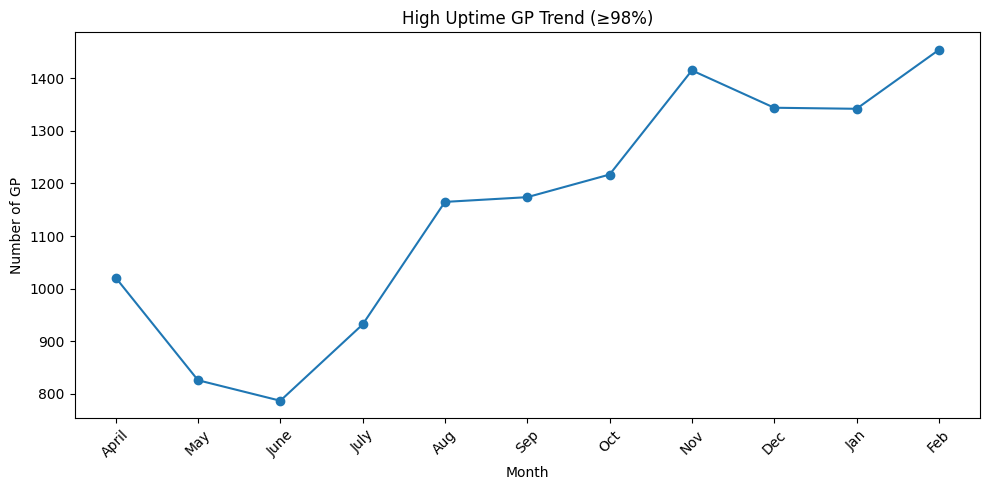

In [8]:
high = data_clean.iloc[0,1:]

plt.figure(figsize=(10,5))

plt.plot(months, high, marker='o')

plt.title("High Uptime GP Trend (≥98%)")
plt.xlabel("Month")
plt.ylabel("Number of GP")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("High_Uptime_GP_Trend.png", dpi=300)

plt.show()


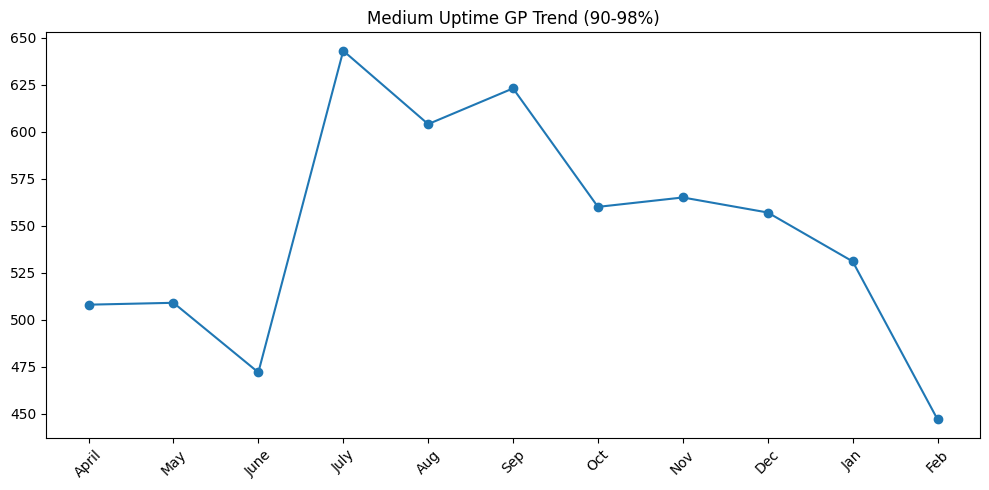

In [9]:
medium = data_clean.iloc[1,1:]

plt.figure(figsize=(10,5))

plt.plot(months, medium, marker='o')

plt.title("Medium Uptime GP Trend (90-98%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("Medium_Uptime_GP_Trend.png", dpi=300)

plt.show()


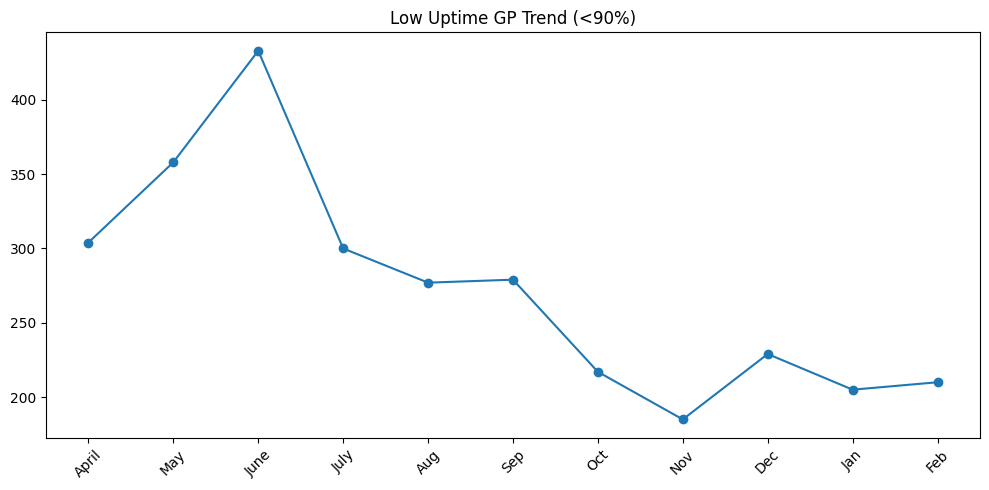

In [10]:
low = data_clean.iloc[2,1:]

plt.figure(figsize=(10,5))

plt.plot(months, low, marker='o')

plt.title("Low Uptime GP Trend (<90%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("Low_Uptime_GP_Trend.png", dpi=300)

plt.show()


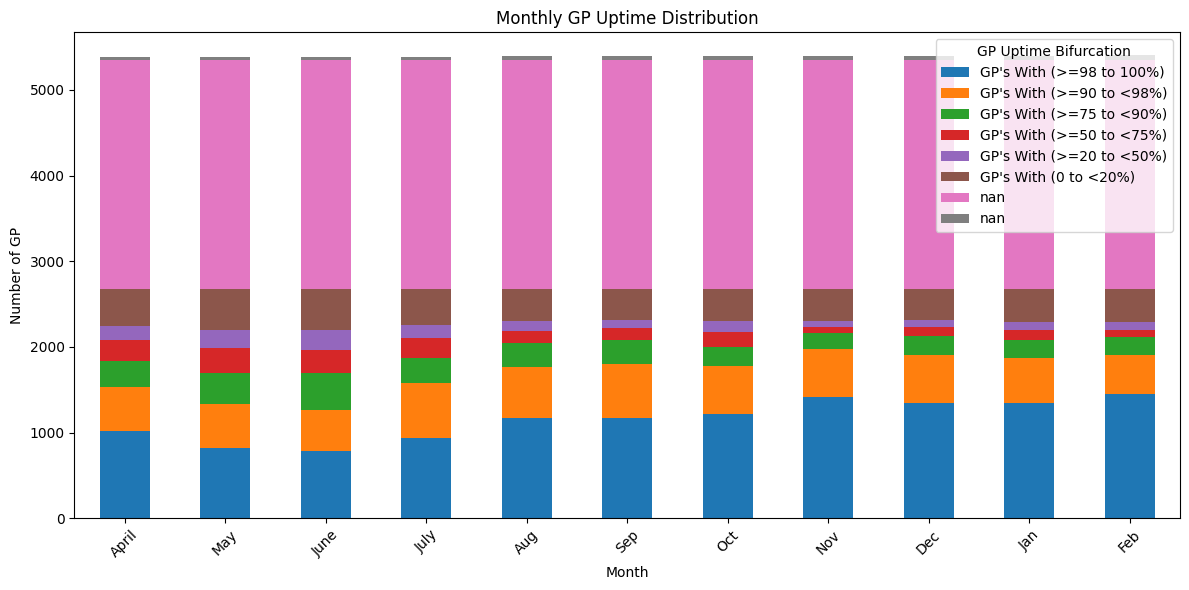

In [11]:
df = data_clean.set_index("GP Uptime Bifurcation")

df.T.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Monthly GP Uptime Distribution")

plt.xlabel("Month")
plt.ylabel("Number of GP")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("monthly_uptime_distribution.png", dpi=300)

plt.show()


In [12]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

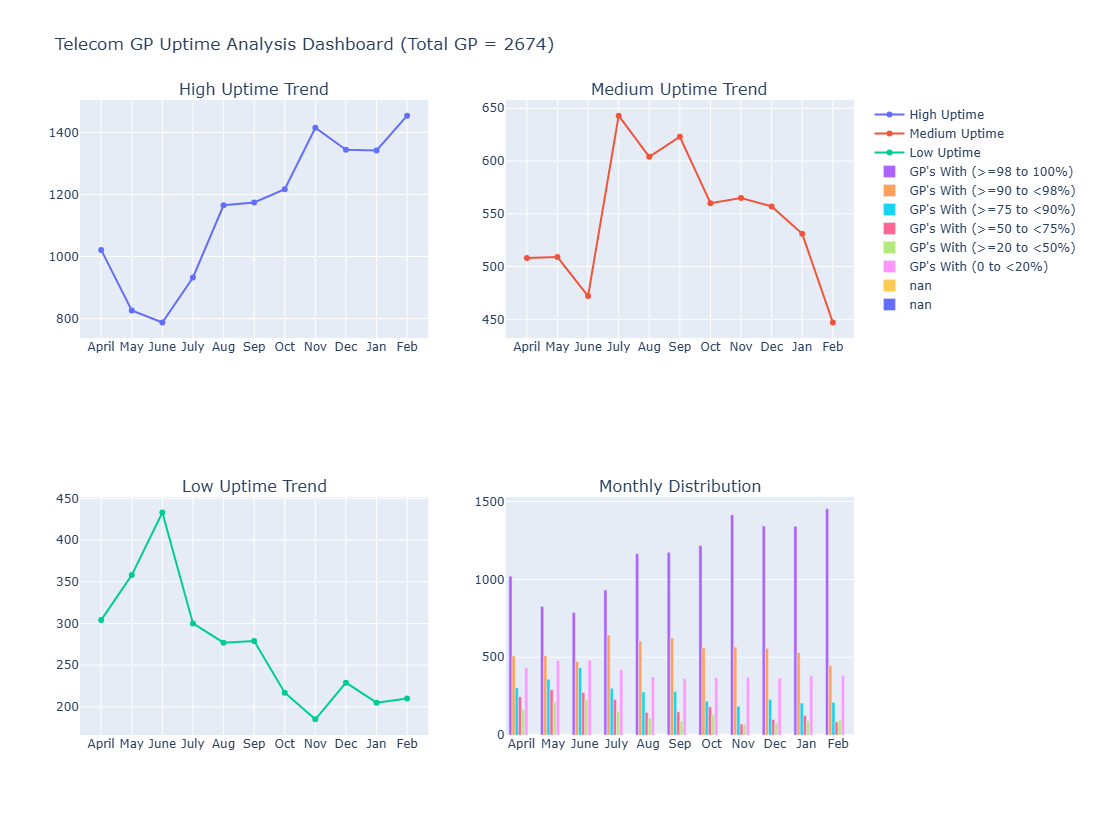

In [13]:
fig = make_subplots(
rows=2,
cols=2,
subplot_titles=("High Uptime Trend","Medium Uptime Trend","Low Uptime Trend","Monthly Distribution")
)

fig.add_trace(
go.Scatter(x=months,y=high,mode='lines+markers',name='High Uptime'),
row=1,col=1
)

fig.add_trace(
go.Scatter(x=months,y=medium,mode='lines+markers',name='Medium Uptime'),
row=1,col=2
)

fig.add_trace(
go.Scatter(x=months,y=low,mode='lines+markers',name='Low Uptime'),
row=2,col=1
)

for i in df.index:
    fig.add_trace(
    go.Bar(x=months,y=df.loc[i],name=i),
    row=2,col=2
    )

fig.update_layout(
title="Telecom GP Uptime Analysis Dashboard (Total GP = 2674)",
height=800,
width=1200
)

fig.show()
fig.write_image("Uptime_Analysis.png")